# Numerical Modeling of the 1-D Advection Equation

**Methods:** Upwind, Lax–Wendroff (Leith), and CIP schemes; NumPy, Matplotlib

### Overview
This notebook compares three advection schemes across Courant numbers for stability and numerical diffusion/dispersion.

----

This notebook investigates different numerical approximations for the one-dimensional hyperbolic advection equation. The comparison demonstrates that a higher-order method does not necessarily guarantee a more accurate result, as unstable conditions and numerical artifacts can still arise depending on the simulation parameters.

The following equation is considered with an initial square pulse defined over the interval $x \in [40,60]$:

\begin{equation*}
\frac{\partial f}{\partial t}+u\left(\frac{\partial f}{\partial x}\right) = 0
\end{equation*}

Three numerical schemes are implemented to model the evolution of $f$:

1. An upwind scheme.
2. Leith's scheme.
3. A CIP scheme.

The outputs of the three models are compared visually by plotting their results on a single chart. Their accuracy and numerical behavior are further examined under different Courant number values to investigate the sources of instability and artificial numerical errors.

#### Import Necessary library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Image as IPyImage

#### Create functions

In [2]:
def upwind_solver(f, u, dx, dt):
    iup = int(np.sign(u))
    return f + u*(dt/dx)* (np.roll(f, iup)-f)

def leith_solver(f, u, dx, dt):
  dt = np.abs(dt)
  a = (1/(2*dx*dx))*(np.roll(f, 1)-2*f+np.roll(f, -1))
  b = (1/(2*dx))*(np.roll(f, -1)-np.roll(f, 1))
  c = f
  return a*(u*dt)**2 - b*u*dt + c

def cip_solver(f, g,  u, dx, dt):
  dt = np.abs(dt)
  iup = int(np.sign(u))
  dxiup = -1.0 *iup*dx
  a = -2.0*(np.roll(f, iup) - f)/(dxiup**3) + (g + np.roll(g, iup))/(dxiup**2)
  b = -3.0*(f - np.roll(f, iup))/(dxiup**2) - (2.0*g + np.roll(g, iup))/(dxiup)
  xi = -1.0*u*dt
  f = a*xi**3 + b*xi**2 + g *xi + f
  g = 3.0*a*xi**2 + 2.0*b*xi + g
  return f, g

Defining initial condition

Text(0.5, 1.0, 'Initial')

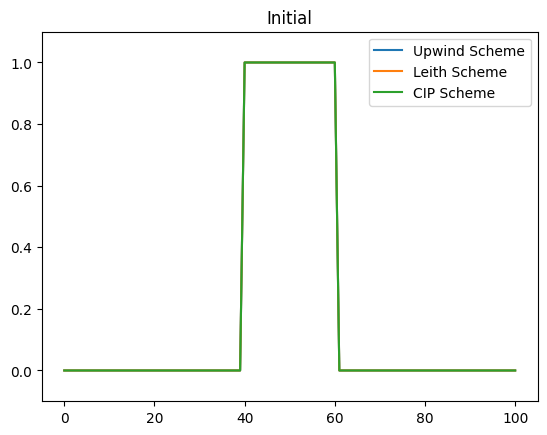

In [3]:
u = 1.0
C = 0.1
dx = 1.0
dt = C*dx/u
Nx = 101
x = np.arange(0.0, Nx*dx, dx)

f = np.zeros_like(x)
f[(x>=40.0)&(x<=60.0)] = 1.0
f_up = np.copy(f)
f_leith = np.copy(f)
f_cip = np.copy(f)
plt.plot(x, f_up, label = 'Upwind Scheme')
plt.plot(x, f_leith, label = 'Leith Scheme')
plt.plot(x, f_cip, label = 'CIP Scheme')
plt.legend()
plt.ylim([-0.1, 1.1])

plt.title('Initial')

From First-order upwind difference method :
\begin{equation}
  f_i^{n+1} = f_i^n + \frac{u \Delta t}{\Delta x} (f_{i_{up}}^n - f_i^n)
\end{equation}

where `iup = sign(u)`

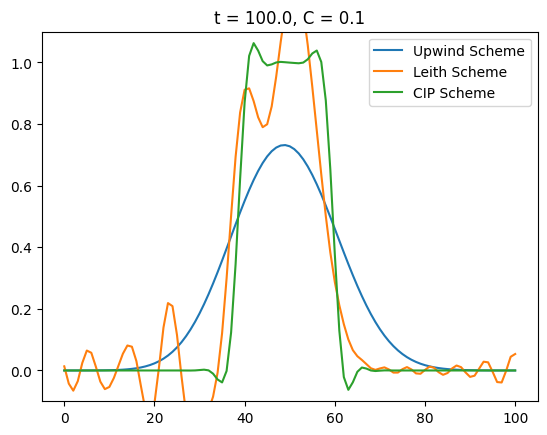

In [4]:
f = np.zeros_like(x)
f[(x>=40.0)&(x<=60.0)] = 1.0
g = (f - np.roll(f, int(np.sign(u))))/dx
f_up = np.copy(f)
f_leith = np.copy(f)
f_cip = np.copy(f)

end_n = int(100 / dt)
for n in range(0, end_n+1):
  if n == end_n :
    plt.plot(x, f_up, label = 'Upwind Scheme')
    plt.plot(x, f_leith, label = 'Leith Scheme')
    plt.plot(x, f_cip, label = 'CIP Scheme')

    plt.legend()
    plt.title(f't = {round(n*dt, 2)}, C = {C}')
    plt.ylim([-0.1, 1.1])
  f_up = upwind_solver(f_up, u, dx, dt)
  f_leith = leith_solver(f_leith, u, dx, dt)
  f_cip, g = cip_solver(f_cip, g, u, dx, dt)


Now we compare to other C cases

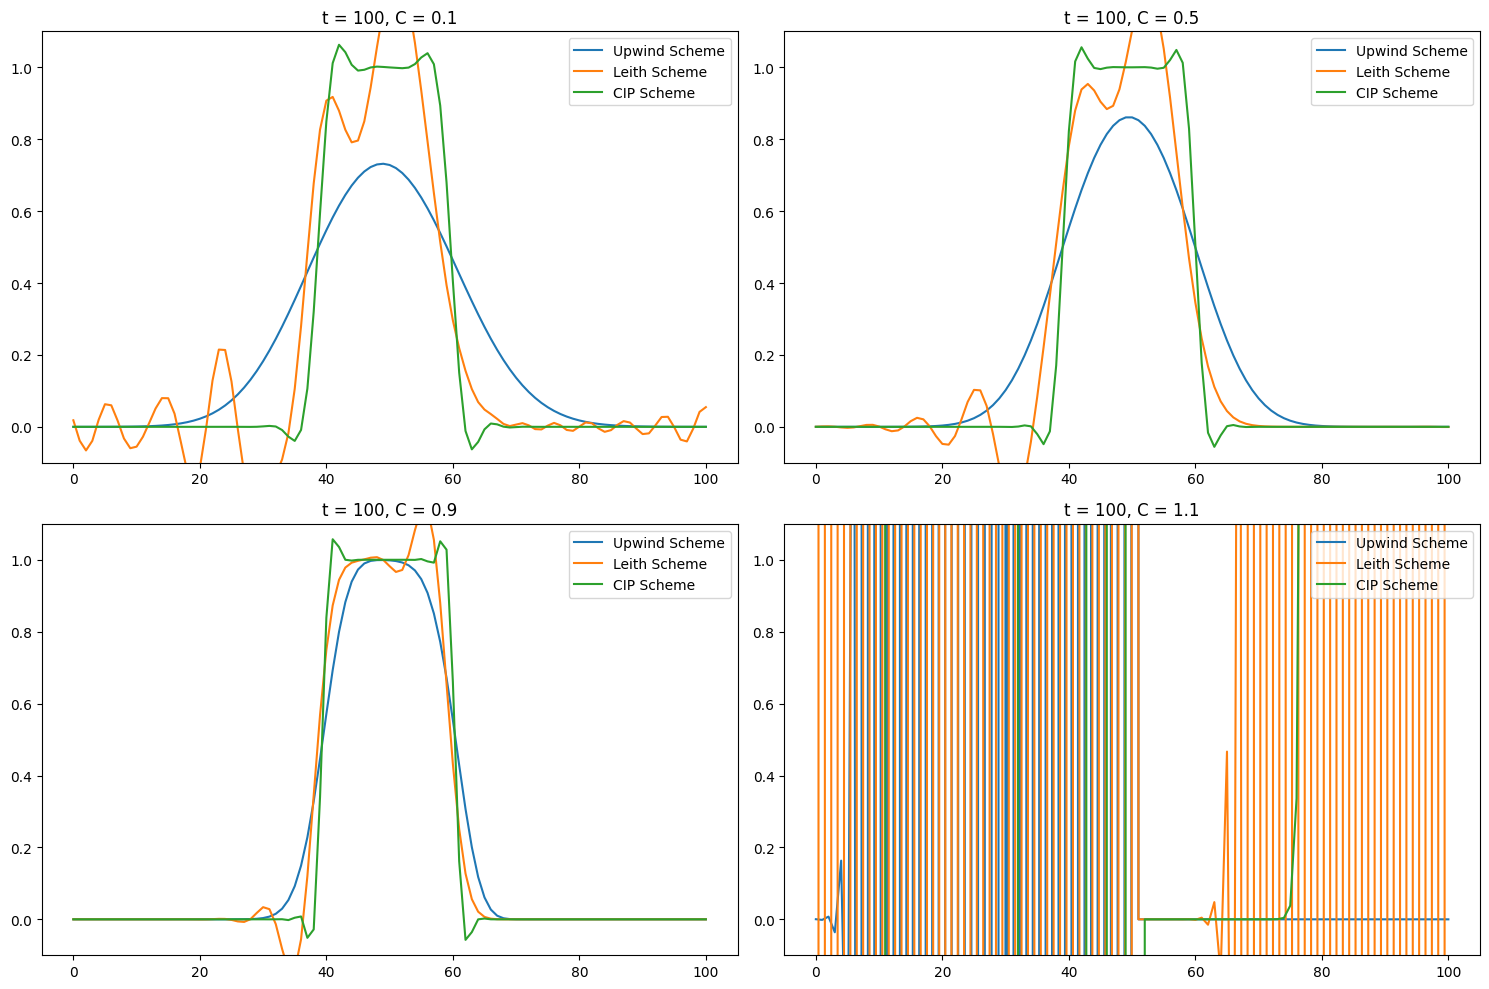

In [5]:
f = np.zeros_like(x)
f[(x>=40.0)&(x<=60.0)] = 1.0
g = (f - np.roll(f, int(np.sign(u))))/dx

fig, ax = plt.subplots(2, 2, figsize=(15, 10))


C = 0.1
dt = C * dx / u
f_up = np.copy(f)
f_leith = np.copy(f)
f_cip = np.copy(f)
g_cip = np.copy(g)
end_n = int(100 / dt)
for n in range(0, end_n + 1):
    f_up = upwind_solver(f_up, u, dx, dt)
    f_leith = leith_solver(f_leith, u, dx, dt)
    f_cip, g_cip = cip_solver(f_cip, g_cip, u, dx, dt)
ax[0, 0].plot(x, f_up, label='Upwind Scheme')
ax[0, 0].plot(x, f_leith, label='Leith Scheme')
ax[0, 0].plot(x, f_cip, label='CIP Scheme')
ax[0, 0].legend()
ax[0, 0].set_title(f't = {int((end_n + 1) * dt)}, C = {C}')
ax[0, 0].set_ylim([-0.1, 1.1])


C = 0.5
dt = C * dx / u
f_up = np.copy(f)
f_leith = np.copy(f)
f_cip = np.copy(f)
g_cip = np.copy(g)
end_n = int(100 / dt)
for n in range(0, end_n + 1):
    f_up = upwind_solver(f_up, u, dx, dt)
    f_leith = leith_solver(f_leith, u, dx, dt)
    f_cip, g_cip = cip_solver(f_cip, g_cip, u, dx, dt)
ax[0, 1].plot(x, f_up, label='Upwind Scheme')
ax[0, 1].plot(x, f_leith, label='Leith Scheme')
ax[0, 1].plot(x, f_cip, label='CIP Scheme')
ax[0, 1].legend()
ax[0, 1].set_title(f't = {int((end_n + 1) * dt)}, C = {C}')
ax[0, 1].set_ylim([-0.1, 1.1])


C = 0.9
dt = C * dx / u
f_up = np.copy(f)
f_leith = np.copy(f)
f_cip = np.copy(f)
g_cip = np.copy(g)
end_n = int(100 / dt)
for n in range(0, end_n + 1):
    f_up = upwind_solver(f_up, u, dx, dt)
    f_leith = leith_solver(f_leith, u, dx, dt)
    f_cip, g_cip = cip_solver(f_cip, g_cip, u, dx, dt)
ax[1, 0].plot(x, f_up, label='Upwind Scheme')
ax[1, 0].plot(x, f_leith, label='Leith Scheme')
ax[1, 0].plot(x, f_cip, label='CIP Scheme')
ax[1, 0].legend()
ax[1, 0].set_title(f't = {int((end_n + 1) * dt)}, C = {C}')
ax[1, 0].set_ylim([-0.1, 1.1])


C = 1.1
dt = C * dx / u
f_up = np.copy(f)
f_leith = np.copy(f)
f_cip = np.copy(f)
g_cip = np.copy(g)
end_n = int(100 / dt)
for n in range(0, end_n + 1):
    f_up = upwind_solver(f_up, u, dx, dt)
    f_leith = leith_solver(f_leith, u, dx, dt)
    f_cip, g_cip = cip_solver(f_cip, g_cip, u, dx, dt)
ax[1, 1].plot(x, f_up, label='Upwind Scheme')
ax[1, 1].plot(x, f_leith, label='Leith Scheme')
ax[1, 1].plot(x, f_cip, label='CIP Scheme')
ax[1, 1].legend()
ax[1, 1].set_title(f't = {int((end_n + 1) * dt)}, C = {C}')
ax[1, 1].set_ylim([-0.1, 1.1])

plt.tight_layout()
plt.show()

Focus on `C = 1.1`

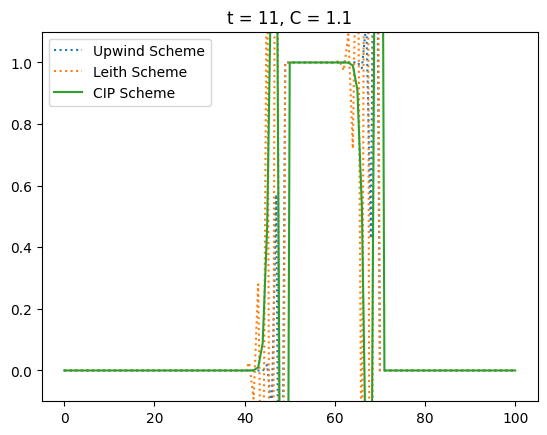

In [6]:
f = np.zeros_like(x)
f[(x>=40.0)&(x<=60.0)] = 1.0
g = (f - np.roll(f, int(np.sign(u))))/dx
C = 1.1
dt = C * dx / u
f_up = np.copy(f)
f_leith = np.copy(f)
f_cip = np.copy(f)
g_cip = np.copy(g)
end_n = int(10 / dt)

for n in range(0, end_n+1):
  if n == end_n :
    plt.plot(x, f_up, label = 'Upwind Scheme', linestyle='dotted')
    plt.plot(x, f_leith, label = 'Leith Scheme', linestyle='dotted')
    plt.plot(x, f_cip, label = 'CIP Scheme')

    plt.legend()
    plt.title(f't = {int((end_n + 1) * dt)}, C = {C}')
    plt.ylim([-0.1, 1.1])
  f_up = upwind_solver(f_up, u, dx, dt)
  f_leith = leith_solver(f_leith, u, dx, dt)
  f_cip, g = cip_solver(f_cip, g, u, dx, dt)


As you can see here, the Upwind and Leith schemes have already become unstable, while the CIP scheme is the least unstable.

### For Video

Import necessary library, and create functions

In [7]:
import os
os.makedirs("frames", exist_ok=True)

import glob
def clear_frames():
  for f in glob.glob("frames/*"):
    os.remove(f)

from tqdm import tqdm

Defining initial condition

In [8]:
u = 1.0
C = 0.1
dx = 1.0
dt = C*dx/u
Nx = 101
x = np.arange(0.0, Nx*dx, dx)

In [9]:
end_n = 1000
step_per_frames = 10
f = np.zeros_like(x)
f[(x>=40.0)&(x<=60.0)] = 1.0
g = (f - np.roll(f, int(np.sign(u))))/dx
f_up = np.copy(f)
f_leith = np.copy(f)
f_cip = np.copy(f)

clear_frames()
pbar = tqdm(total=int(end_n), desc="Video Progress")

for n in range(0, end_n+1):
  if n % step_per_frames == 0:
    fig = plt.figure(figsize=(12, 5))
    plt.plot(x, f_up, label = 'Upwind Scheme')
    plt.plot(x, f_leith, label = 'Leith Scheme')
    plt.plot(x, f_cip, label = 'CIP Scheme')

    plt.legend()
    plt.title(f't = {round(n*dt, 2)}, C = {C}')
    plt.ylim([-0.1, 1.1])
    plt.savefig(f"frames/frame_{n//step_per_frames:05d}.png")
    plt.close(fig)
  f_up = upwind_solver(f_up, u, dx, dt)
  f_leith = leith_solver(f_leith, u, dx, dt)
  f_cip, g = cip_solver(f_cip, g, u, dx, dt)
  pbar.update(1)
pbar.close()

files = sorted(glob.glob("frames/frame_*.png"))
imgs = [Image.open(f) for f in files]
if imgs:
    imgs[0].save("advection_comparison.gif", save_all=True,
                 append_images=imgs[1:], duration=50, loop=0)

# IPyImage(filename="advection_comparison.gif") # render inline in the notebook

#!ffmpeg -framerate 20 -i frames/frame_%05d.png -c:v libx264 -pix_fmt yuv420p -y vid.mp4

Video Progress: 1001it [00:06, 149.72it/s]                         


![Upwind, Leith, and CIP schemes evolving over time](advection_comparison.gif)

### Discussion

The Upwind scheme (1st order) becomes very smooth at low Courant numbers because of numerical diffusion.

The Leith scheme (2nd order) keeps the shape better but may cause oscillations (numerical dispersion), especially at low Courant numbers.

The CIP scheme (high order) is the most accurate overall. It handles sharp edges well and stays stable across a wide range of Courant numbers, though it may have small shifts or errors at very high values.

Even though `C = 0.1` and `C = 0.9` are different, the results are similar because both are still stable and the wave shape is mostly kept. At C = 0.1, the wave moves slowly, and at `C = 0.9`, it moves faster, but both still give good results.

In contrast, `C > 1` is unstable in every case as time increases.
